# Trabajo Práctico 1 — Aprendizaje Profundo
### Carrera de Especialización en Inteligencia Artificial (CEIA)
### Facultad de Ingeniería — Universidad de Buenos Aires (FIUBA)

---

**Alumnos:**
- María Gabriela Di Grazia  — A2517
- Byron Isaac García Miranda — A2524

**Cohorte:** 25Co2026

---

In [1]:
#Agregar librerias necesarias.

import numpy as np
import matplotlib.pyplot as plt

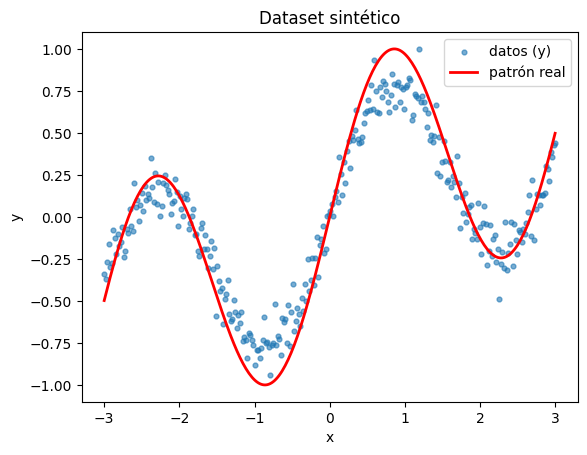

In [2]:
#Ahora bien empezamos creando los datos de entrada
np.random.seed(42)
n = 300
x = np.linspace(-3,3, n)


#Agregamos el patron no lineal 
patron = np.sin(2 * x) + 0.3 * x
ruido = np.random.normal(0, 0.15, size=n)
y = patron + ruido

#Para que pueda ser producible necesitamos que esté entre ~[-1, 1], entonces necesitamos reescalar
y = y / np.max(np.abs(y))


#grafico para entender lo que se ha hecho
plt.scatter(x, y, s=12, alpha=0.6, label="datos (y)")
plt.plot(x, patron / np.max(np.abs(patron)), 'r-', lw=2, label="patrón real")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Dataset sintético")
plt.show()

## Funciones base del modelo

Aquí haremos 3 partes claves del modelo para avanzar, y las piezas claves son:

- forward, el modelo hace su predicción
- J_mse, cuando nos referimos al cálculo del error
- grad, es el cálculo de la corrección

Con esto, el modelo predice con ŷ = tanh(wx + b). Estas funciones se usan una tras otra: se predice → se mide el error → se corrige.

In [ ]:
#Prediccion, costo y gradiente con tanh

def forward(w,b):
    z = w * x + b
    return np.tanh(z)

def J_mse(w,b):
    yhat = forward(w,b)
    return np.mean((yhat - y)**2)

def grad(w,b):
    yhat = forward(w,b)
    e = yhat - y   # (ŷ - y)
    factor = (1 - yhat**2) #derivada de tanh
    dw = (2/n) * np.sum(e * factor * x)
    db = (2/n) * np.sum(e * factor)
    return dw, db

#probamos de que todo cargue bien
print("J de prueba (w=0.5, b=0):", J_mse(0.5, 0.0))

J de prueba (w=0.5, b=0): 0.36719564082237405


## Dataset sintético

El enunciado indicaba contar con una función no lineal que no fuera una `tanh` sola. Elegimos **sin(2x) + 0.3x**: primero, porque el 2 aumenta la frecuencia para que se vean varias oscilaciones en el rango seleccionado de [-3, 3]; y para agregar un poco de inclinación, tomamos la suma de 0.3x, de modo que se rompa un poco la simetría que normalmente tiene el seno.

**Rango [-3, 3]:** Elegimos un rango simétrico respecto al cero, como recomienda el enunciado. El tamaño (±3) lo elegimos para evitar la saturación de la `tanh` y el *vanishing gradient*: con valores muy grandes, `tanh(z) ≈ ±1`, el factor `(1 - ŷ²)` tiende a cero y el gradiente se anula, por lo que el modelo dejaría de aprender.

## 1a) Implementación del Gradiente Descendente

Implementamos el algoritmo de Gradiente Descendente (GD) desde cero para minimizar J(w, b), bajo la siguiente consigna:

- 100 épocas y 3 learning rates: `0.1`, `0.01`, `0.001`
- Inicialización de `w` y `b` aleatoria con `np.random.randn()`
- Graficar J(w, b) vs época, las 3 curvas superpuestas, con distinto color y leyenda

*El optimizador se implementa desde cero (numpy/matplotlib). No se permite PyTorch ni TensorFlow.*

Tenemos el punto inicial: w= 1.7641, b= 0.4002

lr=0.1:  w=1.5285, b=0.0517,  J final=0.52363
lr=0.01:  w=1.7497, b=0.3292,  J final=0.54001
lr=0.001:  w=1.7628, b=0.3925,  J final=0.54470


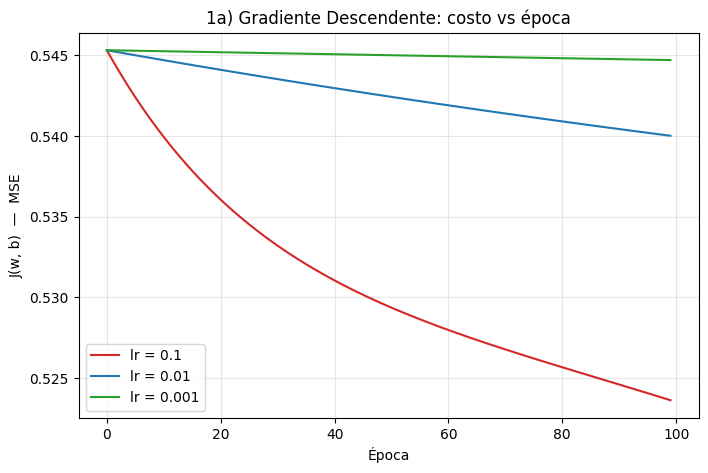

In [11]:
# Inicializamos los paramentros de forma aleatoria
np.random.seed(0)
w_init = np.random.randn()
b_init = np.random.randn()
print(f"Tenemos el punto inicial: w={w_init: .4f}, b={b_init: .4f}\n")

# Como siguiente paso, vamos con la preparacion

epocas = 100
learning_rate = [0.1, 0.01, 0.001]
historias = {}

#creamos un loop por cada learning rate, que seria un loop externo y un loop interno para las epocas

for lr in learning_rate: #este es el loop externo que se hace para la lista de learning rate
    w, b = w_init, b_init # reset desde el punto inicial
    costos = [J_mse(w,b)] #inicializamos la lista de costos

    for epoca in range (epocas-1):
        dw, db = grad(w,b) #se hace el calculo del gradiente, la pendiente
        w = w  - lr * dw 
        b = b - lr * db
        costos.append(J_mse(w,b)) #se calcula el costo y se agrega a la lista de costos
    
    historias[lr] = costos
    print(f"lr={lr}:  w={w:.4f}, b={b:.4f},  J final={costos[-1]:.5f}")


#Grafiquemos para ver como se visualiza curva

plt.figure(figsize=(8,5))
colores = {0.1: 'tab:red', 0.01: 'tab:blue', 0.001: 'tab:green'}
for lr in learning_rate:
    plt.plot(historias[lr], color=colores[lr], label=f"lr = {lr}")

plt.xlabel("Época")
plt.ylabel("J(w, b)  —  MSE")
plt.title("1a) Gradiente Descendente: costo vs época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Conclusión 1a

El learning rate con mejor rendimiento fue **0.1**, que bajó el costo más rápido en las 100 épocas. El lr = 0.001 apenas se movió, porque da pasos muy pequeños y con solo 100 épocas se queda corto.

Se observa que el learning rate y la cantidad de épocas están relacionados: un lr pequeño necesitaría muchas más épocas para converger. De hecho, ninguno de los tres llegó a converger del todo en las 100 épocas.

<br><br>

## 1b) Implementación de Adam

Implementamos el optimizador Adam desde cero para minimizar J(w, b), reutilizando el mismo dataset y funciones del 1a. La consigna:

- Mismos `w` y `b` iniciales que en GD (importante, para comparación justa)
- 100 épocas y los 3 learning rates: `0.1`, `0.01`, `0.001`
- Dos versiones: **full-batch** (todos los datos por época) y **mini-batch** (batch size ≥ 16)
- Graficar J(w, b) vs época en 2 plots separados: uno para full-batch, otro para mini-batch

*Adam se implementa desde cero (numpy/matplotlib). No se permite PyTorch ni TensorFlow.*